In [1]:
from pathlib import Path
from typing import Union
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt
import warnings
import logging

warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
MODEL_DIR = BASE_DIR / "models"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

RANDOM_STATE = 42

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
df_raw = read_zipped_csv(BRFSS_HARMONIZED_CLEAN_ZIP_FILE)
logging.info(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")
logging.info(f"Years covered: {sorted(df_raw['YEAR'].unique())}")

2026-02-22 13:30:40 - INFO - Initial data loaded with 3101950 rows. and columns: 27
2026-02-22 13:30:40 - INFO - Years covered: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3101950 entries, 0 to 3101949
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             int64  
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            int64  
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   int64  
 14  SMOKER                     int64  
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              int64  
 17  POOR_PHYSICAL_HEALTH_DAYS  int64  
 18  POOR_MENTAL_HEALTH_DAYS    int64  
 19  PRE_DIABETES               int64  
 20  GE

<Axes: title={'center': 'Predictor Stability Over Time'}>

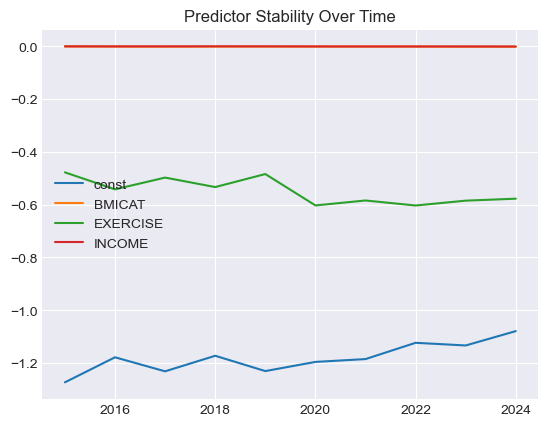

In [6]:
coefs = []

for yr in sorted(df_raw["YEAR"].unique()):
    subset = df_raw[df_raw["YEAR"]==yr]
    X = subset[["BMICAT","EXERCISE","INCOME"]]
    X = sm.add_constant(X)
    y = subset["DIABETES"]
    model = sm.Logit(y, X).fit(disp=False)
    coefs.append(model.params)

coef_df = pd.DataFrame(coefs, index=sorted(df_raw["YEAR"].unique()))
coef_df.plot(title="Predictor Stability Over Time")